# 경복궁 리뷰 EDA

세 사이트(kakao / tripadvisor / tripdotcom) 리뷰의 **별점 · 텍스트 길이 · 날짜** 분포와 이상치를 파악한다.

In [ ]:
## 한글 폰트
!pip install -q koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 24.2 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import os
import re
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import koreanize_matplotlib  # noqa: F401  (import만으로 폰트 적용)
except ImportError:
    plt.rcParams["font.family"] = "DejaVu Sans"


plt.rcParams["axes.unicode_minus"] = False

RATING_MIN, RATING_MAX = 1.0, 5.0
DATE_FORMAT = "%Y년 %m월 %d일"


def parse_dates(s: pd.Series, ref_date: Optional[pd.Timestamp] = None) -> pd.Series:
    """다양한 형태의 날짜 문자열을 datetime으로 파싱한다.

    처리 대상:
      - "2025년 11월 1일"  : 표준 형태
      - "6월 5일"          : 연도 누락 → ref_date의 연도로 보정
                             (보정 결과가 미래면 전년도로 처리)
      - "3일 전"           : 상대 표현 → ref_date 기준 역산
      - "3주 전", "2개월 전", "1년 전"도 동일하게 역산

    Args:
        s: 날짜 문자열 시리즈.
        ref_date: 상대 표현의 기준일. 기본값은 오늘.

    Returns:
        datetime64 시리즈. 파싱 불가한 값은 NaT.
    """
    ref = ref_date if ref_date is not None else pd.Timestamp.today().normalize()
    out = pd.to_datetime(s, format=DATE_FORMAT, errors="coerce")

    unit_days = {"일": 1, "주": 7, "개월": 30, "달": 30, "년": 365}

    for idx in out[out.isna()].index:
        raw = str(s.loc[idx]).strip()

        # "N일 전" / "N주 전" / "N개월 전" / "N년 전"
        m = re.match(r"(\d+)\s*(일|주|개월|달|년)\s*전", raw)
        if m:
            n, unit = int(m.group(1)), m.group(2)
            out.loc[idx] = ref - pd.Timedelta(days=n * unit_days[unit])
            continue

        # "6월 5일" (연도 누락)
        m = re.match(r"(\d{1,2})월\s*(\d{1,2})일", raw)
        if m:
            month, day = int(m.group(1)), int(m.group(2))
            try:
                cand = pd.Timestamp(year=ref.year, month=month, day=day)
            except ValueError:
                continue
            # 보정 결과가 기준일보다 미래면 작년으로 간주
            if cand > ref:
                cand = cand.replace(year=ref.year - 1)
            out.loc[idx] = cand

    return out


class ReviewEDA:
    """단일 사이트 리뷰 데이터의 EDA를 수행한다.

    Attributes:
        site: 사이트 이름 (그래프 제목·리포트에 사용).
        df: 원본 데이터프레임 (분석용 파생 컬럼이 추가됨).
        report: 분포·이상치 요약 딕셔너리.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        site: str,
        date_range: Optional[tuple] = None,
    ) -> None:
        self.site = site
        self.df = df.copy()
        self.report: Dict[str, object] = {}
        self.date_range = date_range
        self._prepare()
        if date_range is not None:
            self._apply_date_range(date_range)

    def _apply_date_range(self, date_range: tuple) -> None:
        """사이트간 비교를 위해 공통 기간만 남긴다.

        사이트마다 수집된 시기가 달라(크롤링 정렬 방식 차이) 원본 그대로
        비교하면 시계열 축이 어긋난다. 공통 구간으로 잘라 비교 가능성을
        확보하되, 잘려나간 건수를 리포트에 남긴다.
        """
        lo, hi = pd.Timestamp(date_range[0]), pd.Timestamp(date_range[1])
        before = len(self.df)
        mask = self.df["parsed_date"].between(lo, hi)
        self.df = self.df[mask].copy()
        self.report["date_range_filter"] = {
            "구간": (str(lo.date()), str(hi.date())),
            "필터 전": before,
            "필터 후": len(self.df),
            "제외": before - len(self.df),
        }

    # --------------------------------------------------------------
    def _prepare(self) -> None:
        """분석용 파생 컬럼(길이·파싱된 날짜)을 생성한다."""
        self.df["text_len"] = self.df["content"].astype("string").str.len()
        self.df["parsed_date"] = parse_dates(self.df["date"])
        self.df["rating"] = pd.to_numeric(self.df["rating"], errors="coerce")

    # --------------------------------------------------------------
    def basic_info(self) -> Dict[str, object]:
        """기본 현황(건수·결측치·중복)을 집계한다."""
        n = len(self.df)
        null_content = int(self.df["content"].isna().sum())
        dup = int(self.df["content"].dropna().duplicated().sum())

        valid = self.df.dropna(subset=["content"]).drop_duplicates(subset=["content"])
        valid = valid[valid["content"].astype(str).str.strip().str.len() >= 2]

        info = {
            "총 건수": n,
            "content 결측": null_content,
            "content 중복": dup,
            "유효 건수(결측·중복·1글자 제외)": len(valid),
        }
        self.report["basic"] = info
        return info

    # --------------------------------------------------------------
    def rating_dist(self) -> Dict[str, object]:
        """별점 분포와 범위 이상치를 집계한다."""
        r = self.df["rating"]
        out_of_range = int(((r < RATING_MIN) | (r > RATING_MAX)).sum())
        dist = r.value_counts().sort_index().to_dict()

        info = {
            "분포": dist,
            "평균": round(float(r.mean()), 3),
            "결측": int(r.isna().sum()),
            f"범위({RATING_MIN}~{RATING_MAX}) 밖": out_of_range,
            "최빈 비율": round(float(r.value_counts(normalize=True).max()), 3),
        }
        self.report["rating"] = info
        return info

    # --------------------------------------------------------------
    def length_dist(self) -> Dict[str, object]:
        """텍스트 길이 분포와 이상치 기준을 IQR·백분위 두 방식으로 비교한다.

        리뷰 길이는 강한 우편향 분포라 IQR 상한을 그대로 적용하면
        정보량이 많은 긴 리뷰가 대량 제거된다. 두 기준을 함께 보고
        어느 쪽을 쓸지 판단할 수 있도록 한다.
        """
        L = self.df["text_len"].dropna()
        q1, q3 = L.quantile(0.25), L.quantile(0.75)
        iqr = q3 - q1
        lo_iqr, hi_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        lo_pct, hi_pct = L.quantile(0.01), L.quantile(0.99)

        info = {
            "describe": {k: round(float(v), 1) for k, v in L.describe().to_dict().items()},
            "IQR 기준": (round(float(lo_iqr), 1), round(float(hi_iqr), 1)),
            "IQR 제거 건수": int(((L < lo_iqr) | (L > hi_iqr)).sum()),
            "백분위(1~99%) 기준": (round(float(lo_pct), 1), round(float(hi_pct), 1)),
            "백분위 제거 건수": int(((L < lo_pct) | (L > hi_pct)).sum()),
            "2글자 미만": int((L < 2).sum()),
        }
        self.report["length"] = info
        return info

    # --------------------------------------------------------------
    def date_dist(self, ref_date: Optional[pd.Timestamp] = None) -> Dict[str, object]:
        """날짜 분포와 기간 이상치(파싱 실패·미래·과도한 과거)를 집계한다."""
        ref = ref_date if ref_date is not None else pd.Timestamp.today().normalize()
        d = self.df["parsed_date"]
        valid = d.dropna()

        raw_fail = pd.to_datetime(
            self.df["date"], format=DATE_FORMAT, errors="coerce"
        ).isna().sum()

        info = {
            "표준형식 파싱 실패(보정 전)": int(raw_fail),
            "최종 파싱 실패": int(d.isna().sum()),
            "범위": (str(valid.min().date()), str(valid.max().date())),
            "미래 날짜": int((valid > ref).sum()),
            "10년 이전": int((valid < ref - pd.Timedelta(days=365 * 10)).sum()),
            "연도별 건수": valid.dt.year.value_counts().sort_index().to_dict(),
        }
        self.report["date"] = info
        return info

    # --------------------------------------------------------------
    def detect_outliers(self) -> pd.DataFrame:
        """이상치 유형별 건수를 표로 반환한다."""
        L = self.df["text_len"]
        q1, q3 = L.quantile(0.25), L.quantile(0.75)
        iqr = q3 - q1
        ref = pd.Timestamp.today().normalize()

        rows = [
            ("content 결측", int(self.df["content"].isna().sum())),
            ("content 중복", int(self.df["content"].dropna().duplicated().sum())),
            ("2글자 미만", int((L < 2).sum())),
            ("별점 결측", int(self.df["rating"].isna().sum())),
            ("별점 범위 밖",
             int(((self.df["rating"] < RATING_MIN) | (self.df["rating"] > RATING_MAX)).sum())),
            ("길이 IQR 상한 초과", int((L > q3 + 1.5 * iqr).sum())),
            ("길이 상위 1%(99백분위) 초과", int((L > L.quantile(0.99)).sum())),
            ("날짜 파싱 실패", int(self.df["parsed_date"].isna().sum())),
            ("미래 날짜", int((self.df["parsed_date"] > ref).sum())),
        ]
        out = pd.DataFrame(rows, columns=["이상치 유형", "건수"])
        out["비율(%)"] = (out["건수"] / len(self.df) * 100).round(2)
        self.report["outliers"] = out
        return out

    # --------------------------------------------------------------
    def plot(self, save_dir: Optional[str] = None) -> None:
        """별점·길이·날짜 분포를 2x3 그리드로 시각화한다.

        Args:
            save_dir: 지정 시 PNG로 저장(과제 명세상 review_analysis/plots).
        """
        fig, axes = plt.subplots(2, 3, figsize=(18, 9))
        fig.suptitle(f"[{self.site}] 리뷰 데이터 EDA", fontsize=16, fontweight="bold")

        # 1. 별점 분포
        ax = axes[0, 0]
        vc = self.df["rating"].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color="#4C72B0")
        ax.set_title("별점 분포")
        ax.set_xlabel("별점")
        ax.set_ylabel("건수")
        for x, y in zip(vc.index.astype(str), vc.values):
            ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

        # 2. 텍스트 길이 히스토그램
        ax = axes[0, 1]
        L = self.df["text_len"].dropna()
        ax.hist(L, bins=50, color="#55A868")
        ax.axvline(float(L.quantile(0.99)), color="red", ls="--", label="99%ile")
        q1, q3 = L.quantile(0.25), L.quantile(0.75)
        ax.axvline(float(q3 + 1.5 * (q3 - q1)), color="orange", ls="--", label="IQR 상한")
        ax.set_title("텍스트 길이 분포")
        ax.set_xlabel("길이(자)")
        ax.legend()

        # 3. 텍스트 길이 boxplot
        ax = axes[0, 2]
        ax.boxplot(L, vert=True)
        ax.set_title("텍스트 길이 boxplot")
        ax.set_ylabel("길이(자)")

        # 4. 연도별 리뷰 수
        ax = axes[1, 0]
        yr = self.df["parsed_date"].dropna().dt.year.value_counts().sort_index()
        ax.bar(yr.index.astype(int), yr.values, color="#C44E52")
        ax.set_title("연도별 리뷰 수")
        ax.set_xlabel("연도")

        # 5. 별점별 평균 길이
        ax = axes[1, 1]
        g = self.df.groupby("rating")["text_len"].mean().sort_index()
        ax.bar(g.index.astype(str), g.values, color="#8172B2")
        ax.set_title("별점별 평균 텍스트 길이")
        ax.set_xlabel("별점")
        ax.set_ylabel("평균 길이(자)")

        # 6. 월별 리뷰 수 추이
        ax = axes[1, 2]
        m = self.df["parsed_date"].dropna().dt.to_period("M").value_counts().sort_index()
        ax.plot(m.index.astype(str), m.values, color="#CCB974")
        ax.set_title("월별 리뷰 수 추이")
        step = max(1, len(m) // 10)
        ax.set_xticks(range(0, len(m), step))
        ax.set_xticklabels([str(x) for x in m.index[::step]], rotation=45, ha="right")

        plt.tight_layout()
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            path = os.path.join(save_dir, f"eda_{self.site}.png")
            fig.savefig(path, dpi=120, bbox_inches="tight")
            print(f"  [저장] {path}")
        plt.show()

    # --------------------------------------------------------------
    def run(self, show_plot: bool = True, save_dir: Optional[str] = None) -> Dict[str, object]:
        """전체 EDA를 수행하고 결과를 출력한다."""
        print("=" * 60)
        print(f"  [{self.site}] EDA")
        print("=" * 60)

        if "date_range_filter" in self.report:
            print("\n■ 공통 구간 필터")
            for k, v in self.report["date_range_filter"].items():
                print(f"  {k}: {v}")

        print("\n■ 기본 현황")
        for k, v in self.basic_info().items():
            print(f"  {k}: {v}")

        print("\n■ 별점")
        for k, v in self.rating_dist().items():
            print(f"  {k}: {v}")

        print("\n■ 텍스트 길이")
        for k, v in self.length_dist().items():
            print(f"  {k}: {v}")

        print("\n■ 날짜")
        for k, v in self.date_dist().items():
            print(f"  {k}: {v}")

        print("\n■ 이상치 요약")
        print(self.detect_outliers().to_string(index=False))
        print()

        if show_plot:
            self.plot(save_dir=save_dir)
        return self.report


def compare_sites(edas: Dict[str, ReviewEDA], save_dir: Optional[str] = None) -> pd.DataFrame:
    """사이트간 핵심 지표를 비교하고 비교 그래프를 그린다."""
    rows = []
    for site, e in edas.items():
        b, r, d = e.report["basic"], e.report["rating"], e.report["date"]
        L = e.df["text_len"].dropna()
        rows.append({
            "사이트": site,
            "총 건수": b["총 건수"],
            "유효 건수": b["유효 건수(결측·중복·1글자 제외)"],
            "평균 별점": r["평균"],
            "5점 비율": round(r["분포"].get(5, r["분포"].get(5.0, 0)) / b["총 건수"], 3),
            "평균 길이": round(float(L.mean()), 1),
            "중앙 길이": round(float(L.median()), 1),
            "시작": d["범위"][0],
            "종료": d["범위"][1],
        })
    summary = pd.DataFrame(rows)

    print("=" * 60)
    print("  사이트간 비교")
    print("=" * 60)
    print(summary.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("사이트간 비교", fontsize=15, fontweight="bold")

    # 별점 분포 비교
    ax = axes[0]
    width = 0.25
    for i, (site, e) in enumerate(edas.items()):
        vc = e.df["rating"].value_counts(normalize=True).sort_index()
        ax.bar(np.arange(len(vc)) + i * width, vc.values, width, label=site)
    ax.set_xticks(np.arange(5) + width)
    ax.set_xticklabels([1, 2, 3, 4, 5])
    ax.set_title("별점 분포(비율)")
    ax.legend()

    # 길이 분포 비교
    ax = axes[1]
    ax.boxplot([e.df["text_len"].dropna() for e in edas.values()],
               labels=list(edas.keys()))
    ax.set_title("텍스트 길이 비교")
    ax.set_ylabel("길이(자)")

    # 연도별 추이 비교
    ax = axes[2]
    for site, e in edas.items():
        yr = e.df["parsed_date"].dropna().dt.year.value_counts().sort_index()
        ax.plot(yr.index, yr.values, marker="o", label=site)
    ax.set_title("연도별 리뷰 수")
    ax.set_xlabel("연도")
    ax.legend()

    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, "eda_compare_sites.png")
        fig.savefig(path, dpi=120, bbox_inches="tight")
        print(f"  [저장] {path}")
    plt.show()
    return summary


def run_all(
    paths: Dict[str, str],
    show_plot: bool = True,
    save_dir: Optional[str] = None,
    date_range: Optional[tuple] = None,
) -> Dict[str, ReviewEDA]:
    """여러 사이트 CSV에 대해 EDA를 일괄 수행한다.

    Args:
        paths: {사이트이름: csv경로} 딕셔너리.
        show_plot: 그래프 출력 여부.

    Returns:
        {사이트이름: ReviewEDA} 딕셔너리.
    """
    edas: Dict[str, ReviewEDA] = {}
    for site, path in paths.items():
        df = pd.read_csv(path)
        eda = ReviewEDA(df, site, date_range=date_range)
        eda.run(show_plot=show_plot, save_dir=save_dir)
        edas[site] = eda
    compare_sites(edas, save_dir=save_dir)
    return edas


  [kakao] EDA

■ 기본 현황
  총 건수: 500
  content 결측: 65
  content 중복: 15
  유효 건수(결측·중복·1글자 제외): 418

■ 별점
  분포: {1: 9, 2: 2, 3: 12, 4: 50, 5: 427}
  평균: 4.768
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.854

■ 텍스트 길이
  describe: {'count': 435.0, 'mean': 37.3, 'std': 35.4, 'min': 1.0, '25%': 11.5, '50%': 24.0, '75%': 54.0, 'max': 238.0}
  IQR 기준: (-52.2, 117.8)
  IQR 제거 건수: 12
  백분위(1~99%) 기준: (2.0, 131.7)
  백분위 제거 건수: 7
  2글자 미만: 2

■ 날짜
  표준형식 파싱 실패(보정 전): 0
  최종 파싱 실패: 0
  범위: ('2016-05-26', '2026-07-22')
  미래 날짜: 0
  10년 이전: 2
  연도별 건수: {2016: 3, 2017: 1, 2018: 7, 2019: 9, 2020: 19, 2021: 24, 2022: 36, 2023: 117, 2024: 93, 2025: 128, 2026: 63}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측  65   13.0
        content 중복  15    3.0
            2글자 미만   2    0.4
             별점 결측   0    0.0
           별점 범위 밖   0    0.0
      길이 IQR 상한 초과  12    2.4
길이 상위 1%(99백분위) 초과   5    1.0
          날짜 파싱 실패   0    0.0
             미래 날짜   0    0.0

  [저장] plots/eda_kakao.png


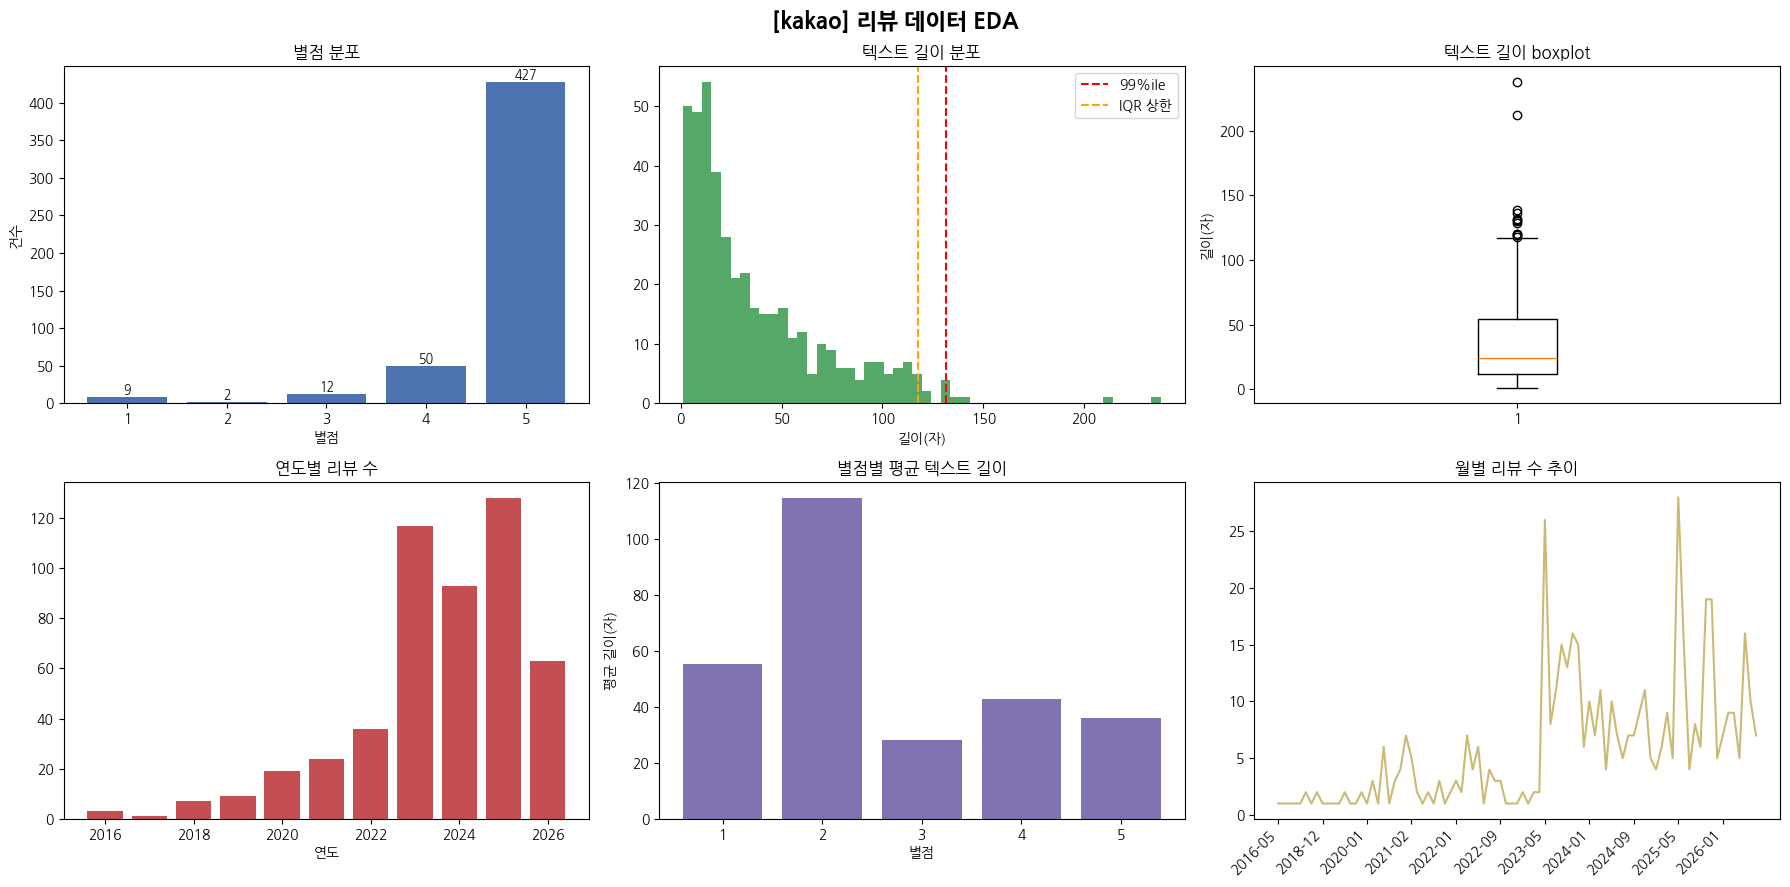

  [tripadvisor] EDA

■ 기본 현황
  총 건수: 1500
  content 결측: 0
  content 중복: 0
  유효 건수(결측·중복·1글자 제외): 1500

■ 별점
  분포: {1: 1, 2: 4, 3: 113, 4: 451, 5: 931}
  평균: 4.538
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.621

■ 텍스트 길이
  describe: {'count': 1500.0, 'mean': 130.3, 'std': 101.6, 'min': 31.0, '25%': 71.8, '50%': 99.0, '75%': 153.2, 'max': 1441.0}
  IQR 기준: (-50.5, 275.5)
  IQR 제거 건수: 102
  백분위(1~99%) 기준: (41.0, 551.0)
  백분위 제거 건수: 27
  2글자 미만: 0

■ 날짜
  표준형식 파싱 실패(보정 전): 0
  최종 파싱 실패: 0
  범위: ('2016-05-04', '2024-11-14')
  미래 날짜: 0
  10년 이전: 269
  연도별 건수: {2016: 711, 2017: 591, 2018: 67, 2019: 69, 2020: 17, 2022: 1, 2023: 7, 2024: 37}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측   0    0.0
        content 중복   0    0.0
            2글자 미만   0    0.0
             별점 결측   0    0.0
           별점 범위 밖   0    0.0
      길이 IQR 상한 초과 102    6.8
길이 상위 1%(99백분위) 초과  15    1.0
          날짜 파싱 실패   0    0.0
             미래 날짜   0    0.0

  [저장] plots/eda_tripadvisor.png


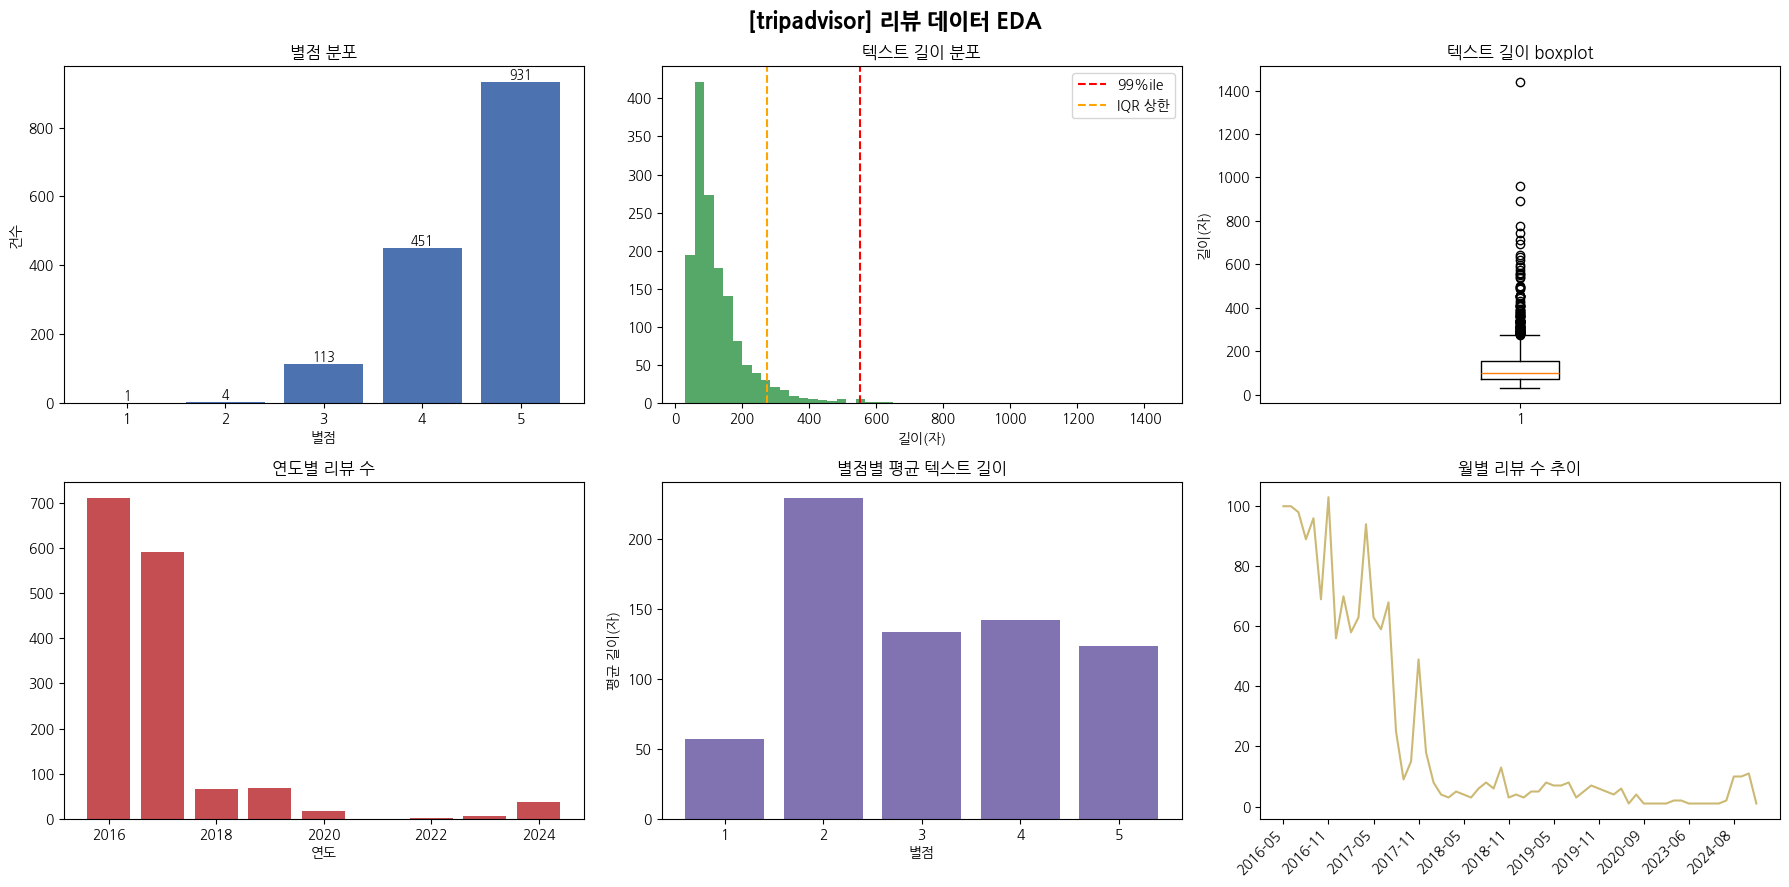

  [tripdotcom] EDA

■ 기본 현황
  총 건수: 1282
  content 결측: 0
  content 중복: 28
  유효 건수(결측·중복·1글자 제외): 1254

■ 별점
  분포: {1.0: 19, 2.0: 11, 3.0: 71, 4.0: 259, 5.0: 922}
  평균: 4.602
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.719

■ 텍스트 길이
  describe: {'count': 1282.0, 'mean': 100.8, 'std': 113.4, 'min': 2.0, '25%': 40.0, '50%': 71.0, '75%': 123.0, 'max': 1447.0}
  IQR 기준: (-84.5, 247.5)
  IQR 제거 건수: 81
  백분위(1~99%) 기준: (3.0, 534.0)
  백분위 제거 건수: 25
  2글자 미만: 0

■ 날짜
  표준형식 파싱 실패(보정 전): 39
  최종 파싱 실패: 1
  범위: ('2011-08-16', '2026-07-21')
  미래 날짜: 0
  10년 이전: 188
  연도별 건수: {2011: 3, 2012: 20, 2013: 21, 2014: 53, 2015: 7, 2016: 91, 2017: 4, 2018: 9, 2019: 201, 2020: 141, 2021: 51, 2022: 110, 2023: 262, 2024: 212, 2025: 58, 2026: 38}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측   0   0.00
        content 중복  28   2.18
            2글자 미만   0   0.00
             별점 결측   0   0.00
           별점 범위 밖   0   0.00
      길이 IQR 상한 초과  81   6.32
길이 상위 1%(99백분위) 초과  13   1.01
          날짜 파싱 실패   1  

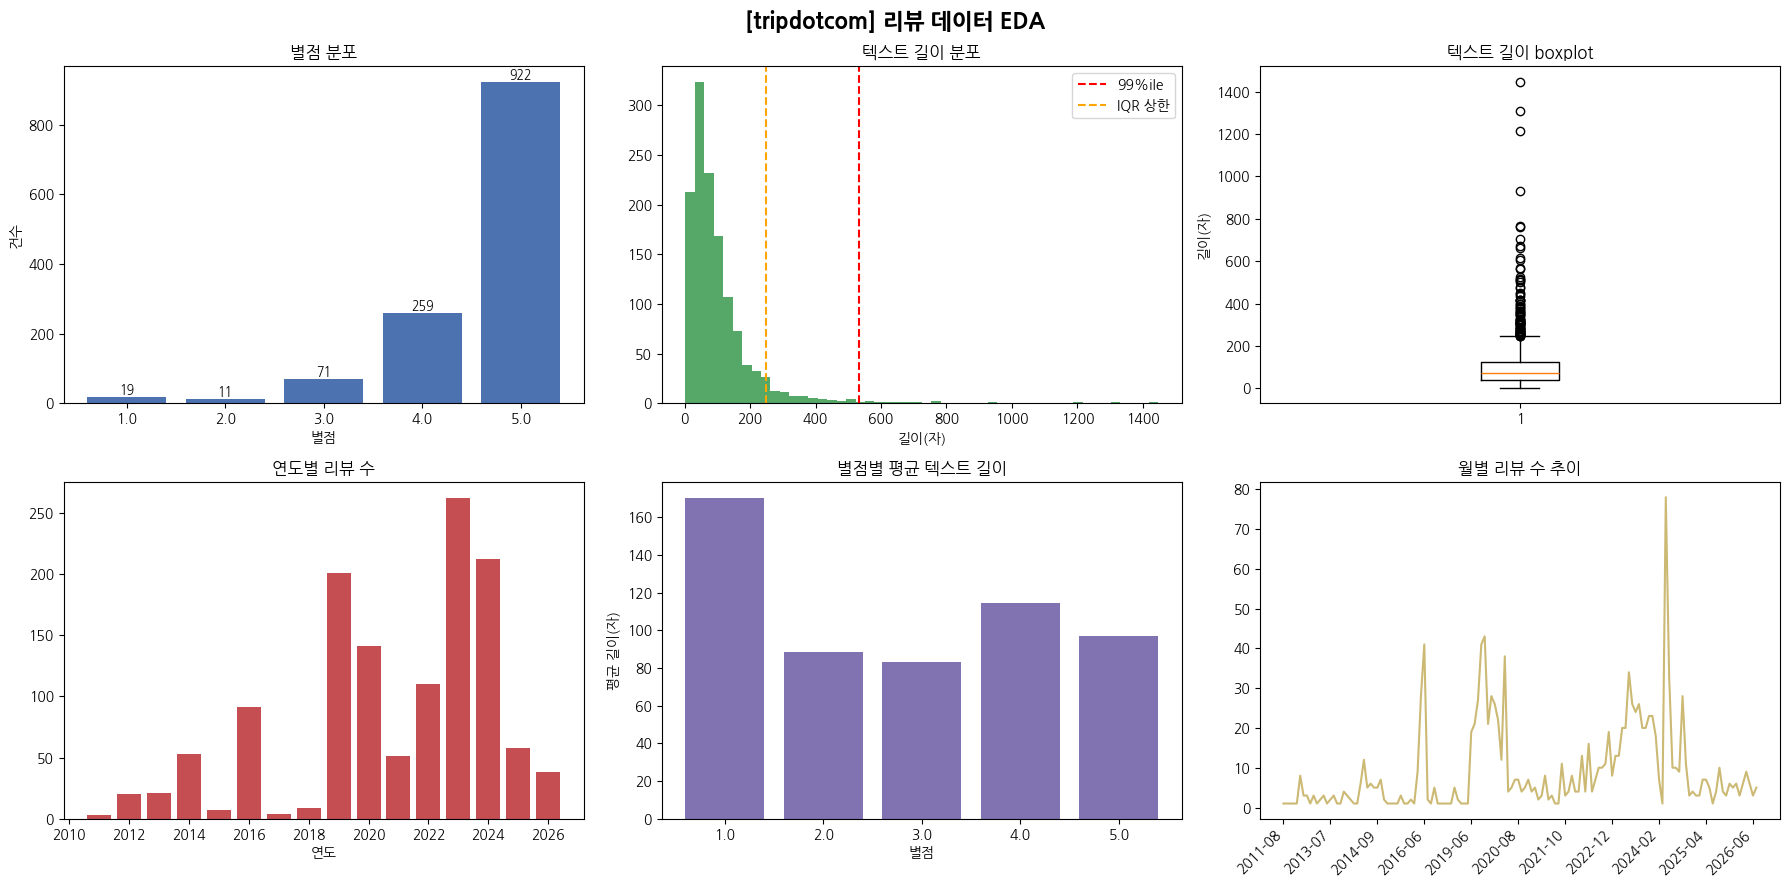

  사이트간 비교
        사이트  총 건수  유효 건수  평균 별점  5점 비율  평균 길이  중앙 길이         시작         종료
      kakao   500    418  4.768  0.854   37.3   24.0 2016-05-26 2026-07-22
tripadvisor  1500   1500  4.538  0.621  130.3   99.0 2016-05-04 2024-11-14
 tripdotcom  1282   1254  4.602  0.719  100.8   71.0 2011-08-16 2026-07-21


/tmp/ipykernel_1418/3744376538.py:376: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([e.df["text_len"].dropna() for e in edas.values()],


  [저장] plots/eda_compare_sites.png


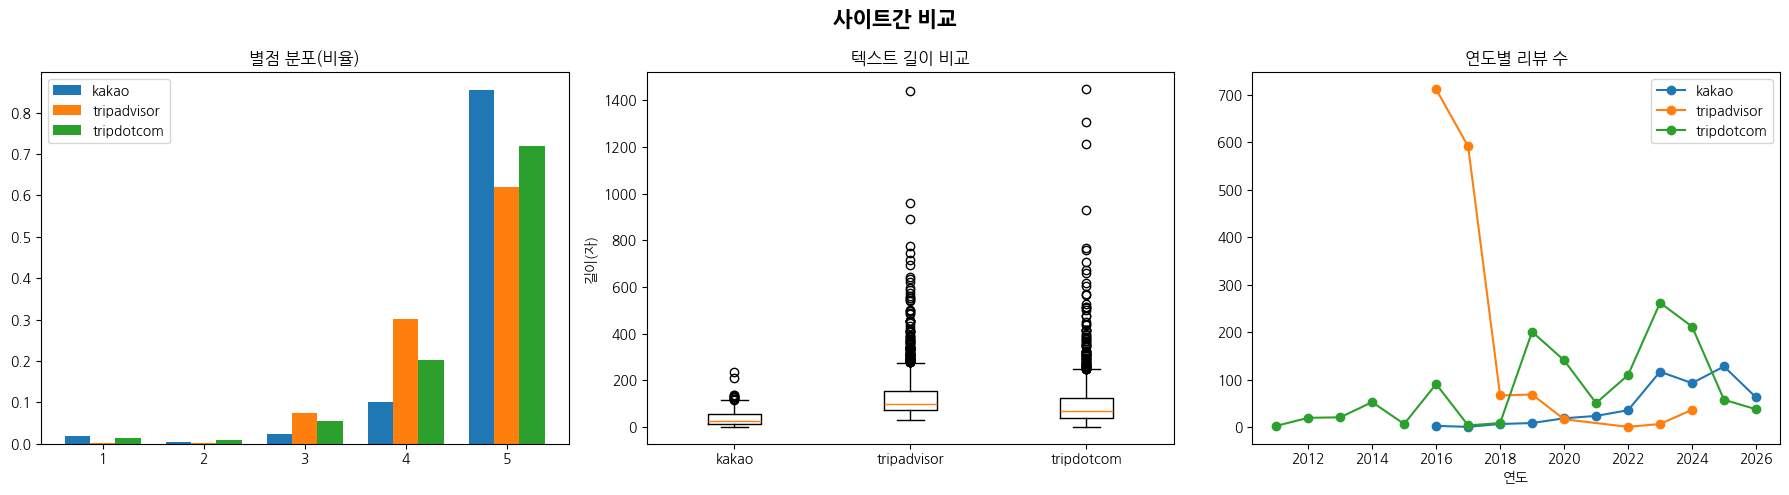

In [ ]:
edas = run_all(
    {
        "kakao": "reviews_kakao.csv",
        "tripadvisor": "reviews_tripadvisor.csv",
        "tripdotcom": "reviews_tripdotcom.csv",
    },
    save_dir="plots",          #
    date_range=None,           # 원본 전체 (개별 EDA용)
)

  [kakao] EDA

■ 공통 구간 필터
  구간: ('2016-05-26', '2024-11-14')
  필터 전: 500
  필터 후: 299
  제외: 201

■ 기본 현황
  총 건수: 299
  content 결측: 38
  content 중복: 12
  유효 건수(결측·중복·1글자 제외): 248

■ 별점
  분포: {1: 5, 2: 2, 3: 7, 4: 30, 5: 255}
  평균: 4.766
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.853

■ 텍스트 길이
  describe: {'count': 261.0, 'mean': 32.7, 'std': 33.2, 'min': 1.0, '25%': 11.0, '50%': 21.0, '75%': 45.0, 'max': 238.0}
  IQR 기준: (-40.0, 96.0)
  IQR 제거 건수: 15
  백분위(1~99%) 기준: (2.0, 115.0)
  백분위 제거 건수: 4
  2글자 미만: 1

■ 날짜
  표준형식 파싱 실패(보정 전): 0
  최종 파싱 실패: 0
  범위: ('2016-05-26', '2024-11-14')
  미래 날짜: 0
  10년 이전: 2
  연도별 건수: {2016: 3, 2017: 1, 2018: 7, 2019: 9, 2020: 19, 2021: 24, 2022: 36, 2023: 117, 2024: 83}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측  38  12.71
        content 중복  12   4.01
            2글자 미만   1   0.33
             별점 결측   0   0.00
           별점 범위 밖   0   0.00
      길이 IQR 상한 초과  15   5.02
길이 상위 1%(99백분위) 초과   3   1.00
          날짜 파싱 실패   0   0.00
             미래 날

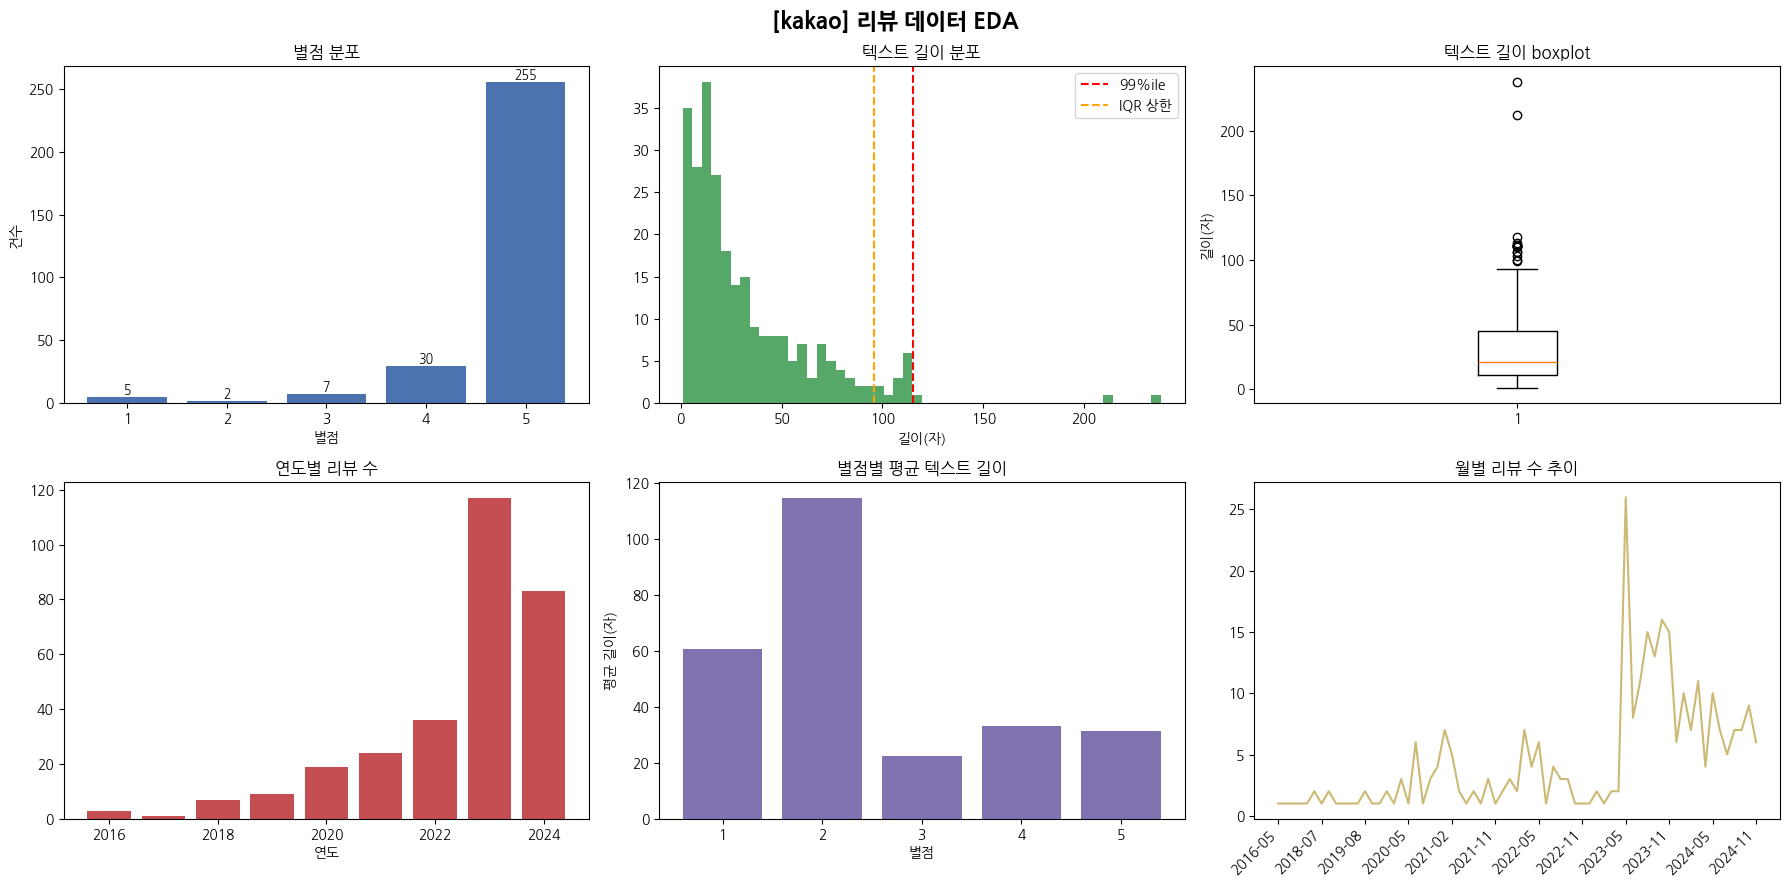

  [tripadvisor] EDA

■ 공통 구간 필터
  구간: ('2016-05-26', '2024-11-14')
  필터 전: 1500
  필터 후: 1422
  제외: 78

■ 기본 현황
  총 건수: 1422
  content 결측: 0
  content 중복: 0
  유효 건수(결측·중복·1글자 제외): 1422

■ 별점
  분포: {1: 1, 2: 4, 3: 107, 4: 420, 5: 890}
  평균: 4.543
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.626

■ 텍스트 길이
  describe: {'count': 1422.0, 'mean': 130.0, 'std': 102.9, 'min': 31.0, '25%': 71.0, '50%': 98.0, '75%': 152.0, 'max': 1441.0}
  IQR 기준: (-50.5, 273.5)
  IQR 제거 건수: 99
  백분위(1~99%) 기준: (41.0, 554.2)
  백분위 제거 건수: 27
  2글자 미만: 0

■ 날짜
  표준형식 파싱 실패(보정 전): 0
  최종 파싱 실패: 0
  범위: ('2016-05-26', '2024-11-14')
  미래 날짜: 0
  10년 이전: 191
  연도별 건수: {2016: 633, 2017: 591, 2018: 67, 2019: 69, 2020: 17, 2022: 1, 2023: 7, 2024: 37}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측   0   0.00
        content 중복   0   0.00
            2글자 미만   0   0.00
             별점 결측   0   0.00
           별점 범위 밖   0   0.00
      길이 IQR 상한 초과  99   6.96
길이 상위 1%(99백분위) 초과  15   1.05
          날짜 파싱 실패   0   0.00
   

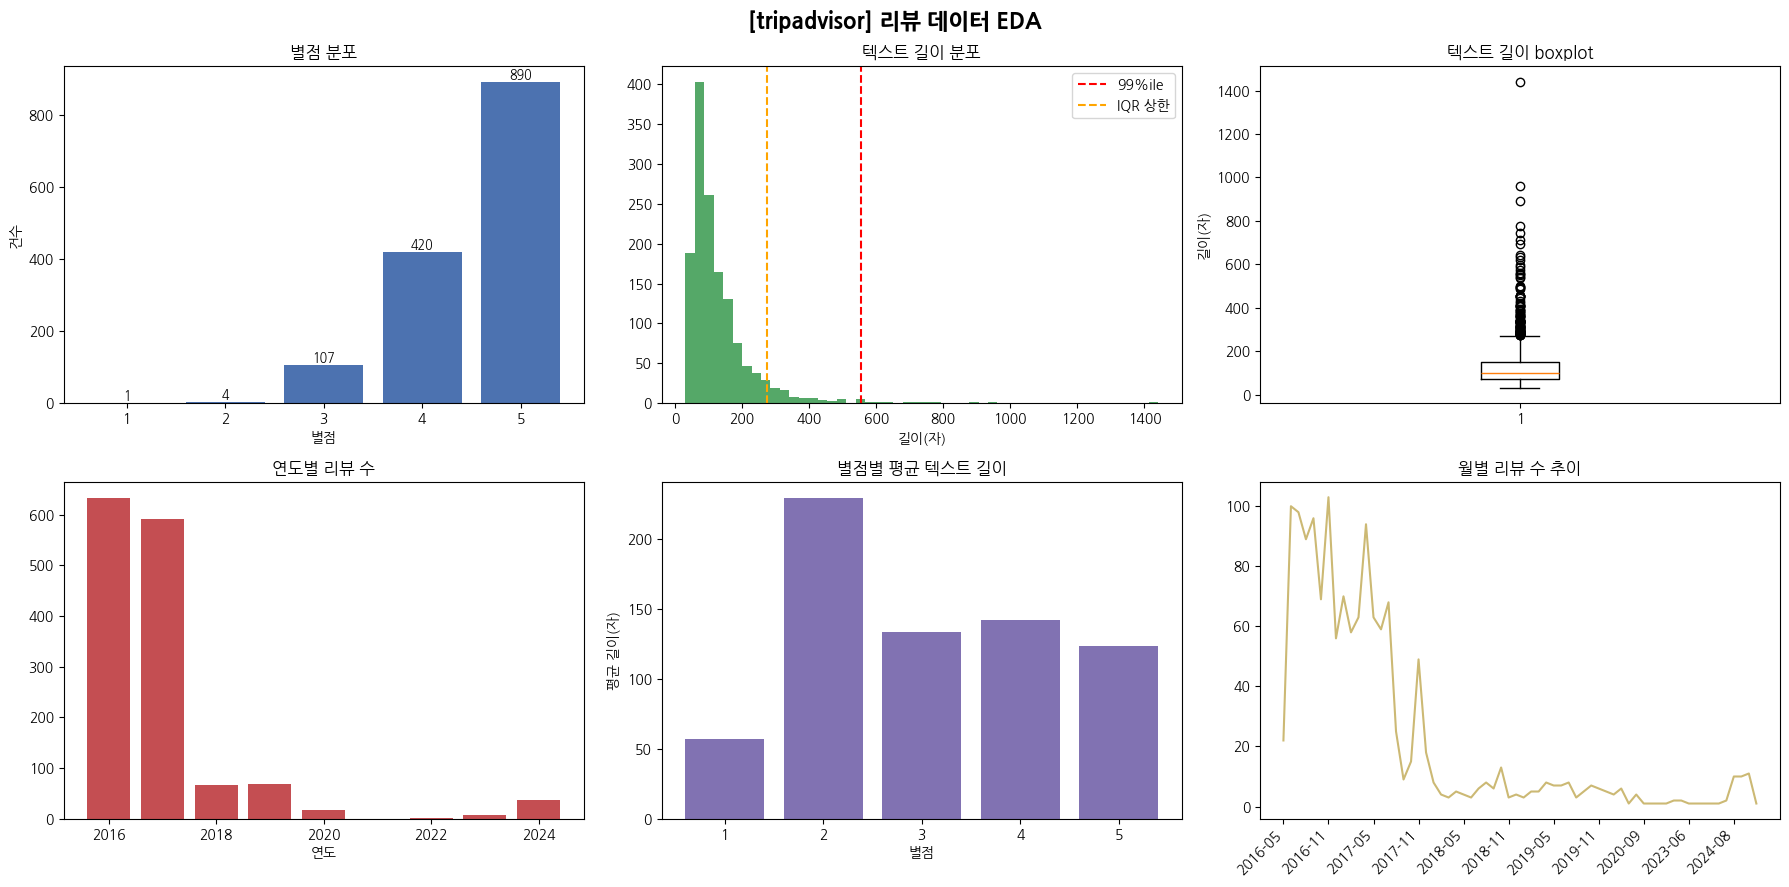

  [tripdotcom] EDA

■ 공통 구간 필터
  구간: ('2016-05-26', '2024-11-14')
  필터 전: 1282
  필터 후: 1041
  제외: 241

■ 기본 현황
  총 건수: 1041
  content 결측: 0
  content 중복: 24
  유효 건수(결측·중복·1글자 제외): 1017

■ 별점
  분포: {1.0: 6, 2.0: 7, 3.0: 39, 4.0: 190, 5.0: 799}
  평균: 4.699
  결측: 0
  범위(1.0~5.0) 밖: 0
  최빈 비율: 0.768

■ 텍스트 길이
  describe: {'count': 1041.0, 'mean': 96.0, 'std': 101.9, 'min': 2.0, '25%': 41.0, '50%': 69.0, '75%': 119.0, 'max': 1447.0}
  IQR 기준: (-76.0, 236.0)
  IQR 제거 건수: 64
  백분위(1~99%) 기준: (2.4, 498.6)
  백분위 제거 건수: 22
  2글자 미만: 0

■ 날짜
  표준형식 파싱 실패(보정 전): 0
  최종 파싱 실패: 0
  범위: ('2016-05-26', '2024-11-08')
  미래 날짜: 0
  10년 이전: 48
  연도별 건수: {2016: 55, 2017: 4, 2018: 9, 2019: 201, 2020: 141, 2021: 51, 2022: 110, 2023: 262, 2024: 208}

■ 이상치 요약
            이상치 유형  건수  비율(%)
        content 결측   0   0.00
        content 중복  24   2.31
            2글자 미만   0   0.00
             별점 결측   0   0.00
           별점 범위 밖   0   0.00
      길이 IQR 상한 초과  64   6.15
길이 상위 1%(99백분위) 초과  11   1.06
          날짜 파

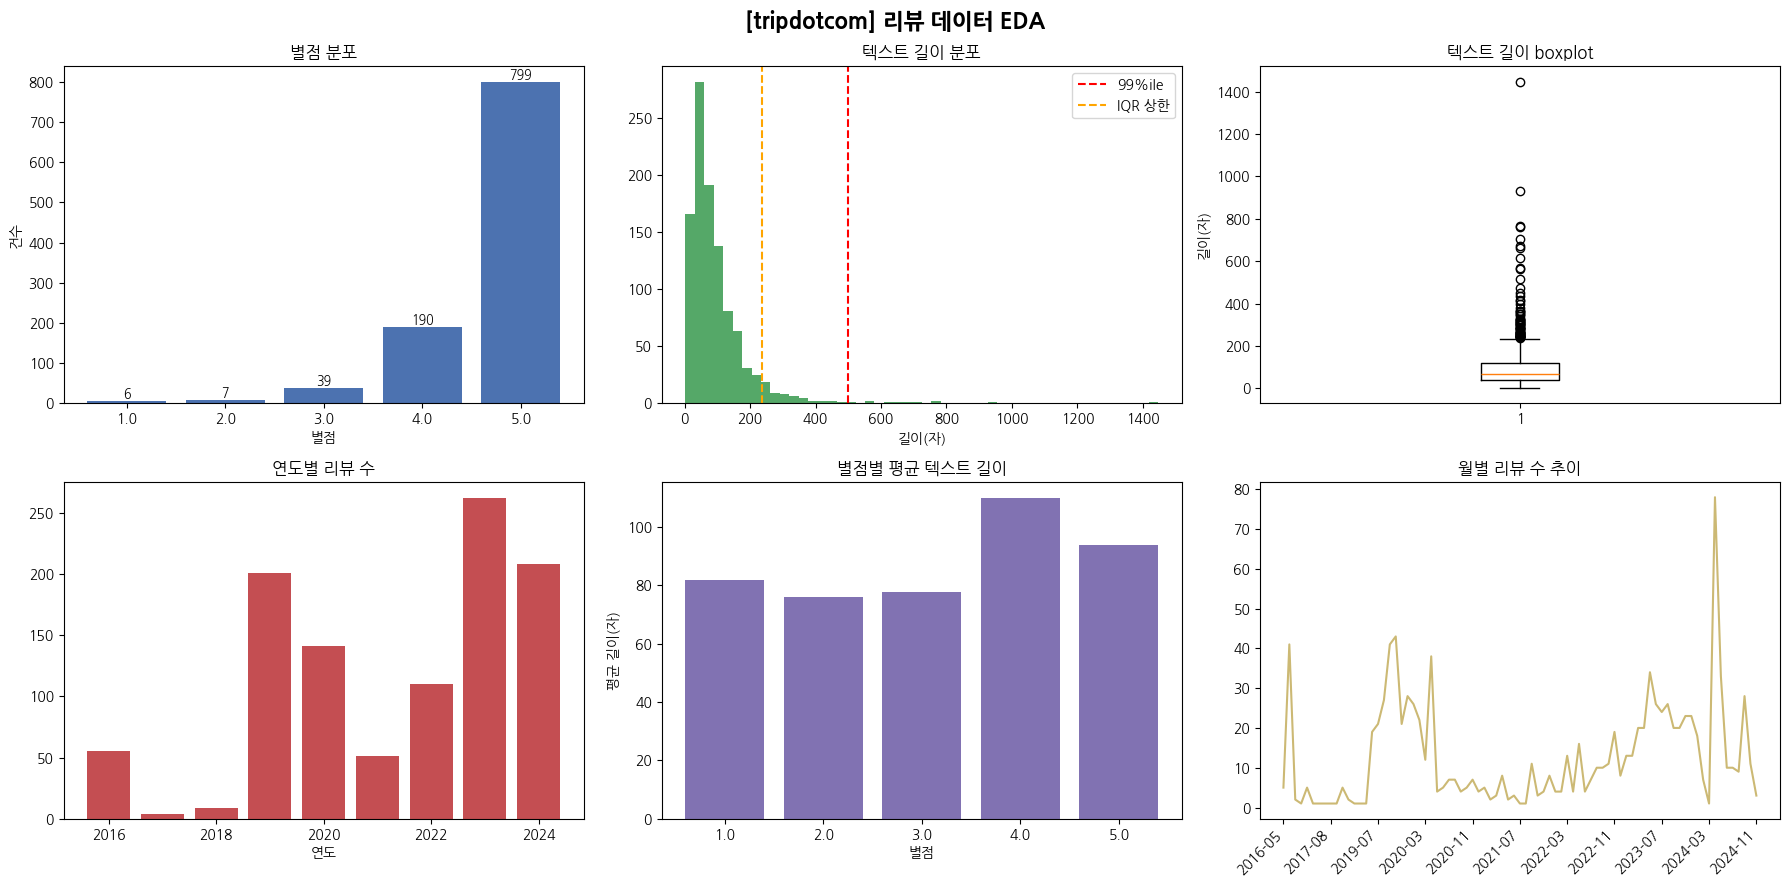

  사이트간 비교
        사이트  총 건수  유효 건수  평균 별점  5점 비율  평균 길이  중앙 길이         시작         종료
      kakao   299    248  4.766  0.853   32.7   21.0 2016-05-26 2024-11-14
tripadvisor  1422   1422  4.543  0.626  130.0   98.0 2016-05-26 2024-11-14
 tripdotcom  1041   1017  4.699  0.768   96.0   69.0 2016-05-26 2024-11-08


/tmp/ipykernel_1418/3744376538.py:376: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([e.df["text_len"].dropna() for e in edas.values()],


  [저장] plots_common/eda_compare_sites.png


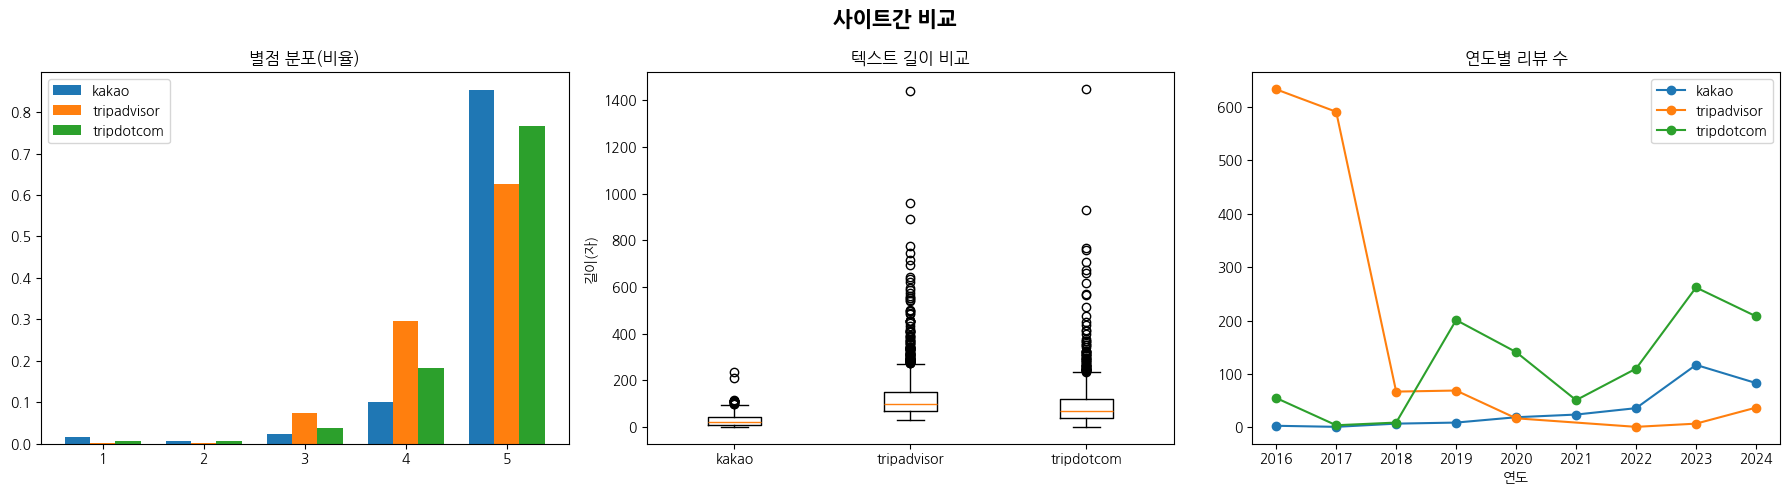

In [ ]:
# 사이트간 비교용: 공통 구간(2016-05-26 ~ 2024-11-14)으로 자른 버전

edas_common = run_all(
    {
        "kakao": "reviews_kakao.csv",
        "tripadvisor": "reviews_tripadvisor.csv",
        "tripdotcom": "reviews_tripdotcom.csv",
    },
    save_dir="plots_common",
    date_range=("2016-05-26", "2024-11-14"),
)

# EDA 요약

## 별점 분포

- 세 사이트 모두 5점 쏠림
  - 카카오 85%, 트립닷컴 72%, 트립어드바이저 62%

---

## 텍스트 길이 분포

- 세 사이트 모두 right skewed 된 분포
  - 짧은 리뷰가 대다수, 긴 리뷰 쪽으로 꼬리가 긺


- 사이트별 평균 텍스트 길이 차이가 존재
  - 카카오 37자, 트립닷컴 101자, 트립어드바이저 130자


---

## 수집 시기

- 사이트마다 수집 시기 상이
  - 크롤링 정렬 방식 차이로 보이며, 실제 방문 추이와는 무관해보임


---

## 이상치

- 날짜, 별점 관련 이상치는 존재하지 않음

- 리뷰 길이 관련 이상치
  - 매우 길이가 긴 리뷰는, 중복되거나 무의미한 스팸이 아닌 실제로 내용을 가지고 작성된 장문의 리뷰임
  - 따라서 실제로 전처리 수행 시, 길이 이상치는 하한만 잘라내는것이 적절해 보임.